Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Immune"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 87639 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Immune-M1,kME_grey,kME_Immune-M2,kME_Immune-M3,kME_Immune-M4,kME_Immune-M5
ENSMUSG00000024610,ENSMUSG00000024610,Immune-M1,yellow,0.559563,-0.026822,0.087691,0.147090,0.058215,0.275142
ENSMUSG00000060586,ENSMUSG00000060586,Immune-M1,yellow,0.869311,0.001982,0.102990,0.249605,0.082369,-0.016836
ENSMUSG00000036594,ENSMUSG00000036594,Immune-M1,yellow,0.865524,0.001619,0.111349,0.246037,0.085992,-0.018585
ENSMUSG00000073421,ENSMUSG00000073421,Immune-M1,yellow,0.813989,-0.001003,0.087103,0.228217,0.082385,0.008726
ENSMUSG00000044162,ENSMUSG00000044162,Immune-M1,yellow,0.766454,0.003662,0.061605,0.206750,0.063295,0.015329


In [5]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,blue,turquoise,green,yellow,brown
TGTGCGGAGTCCTGTA-216_A01,-8.505898,30.283247,0.117752,-0.792412,-1.235391
AAGAACAGTGGTGATG-216_D01,-8.551579,30.065327,-0.688576,-0.734662,-0.581734
ACAGAAATCGACGTCG-471_B04,-7.861430,22.244992,-0.688576,-0.228925,-0.276623
TTGCCTGCAGGAGGAG-216_C01,-9.094108,36.717444,-0.688576,-0.736562,-1.290367
TCCATCGTCTCGCTTG-594_B02,-7.538399,32.596541,0.321969,2.167889,1.802641


In [6]:
# Create a mapping from color to module
color_to_module = modules_df.set_index("color")["module"].to_dict()

# Rename the columns of MEs_df
MEs_df.rename(columns=color_to_module, inplace=True)

# Sort the columns of MEs_df alphabetically
MEs_df = MEs_df.reindex(sorted(MEs_df.columns), axis=1)
MEs_df.head()

,Immune-M1,Immune-M2,Immune-M3,Immune-M4,Immune-M5
TGTGCGGAGTCCTGTA-216_A01,-0.792412,30.283247,-1.235391,0.117752,-8.505898
AAGAACAGTGGTGATG-216_D01,-0.734662,30.065327,-0.581734,-0.688576,-8.551579
ACAGAAATCGACGTCG-471_B04,-0.228925,22.244992,-0.276623,-0.688576,-7.861430
TTGCCTGCAGGAGGAG-216_C01,-0.736562,36.717444,-1.290367,-0.688576,-9.094108
TCCATCGTCTCGCTTG-594_B02,2.167889,32.596541,1.802641,0.321969,-7.538399


In [7]:
# Getting the list of modules
modules = MEs_df.columns.tolist()

In [8]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, MEs_df, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,Immune-M1,Immune-M2,Immune-M3,Immune-M4,Immune-M5
TGTGCGGAGTCCTGTA-216_A01,TGTGCGGAGTCCTGTA,216_A01,L8TX_200206_01_F03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#66493D,#32662E,#EEFF99,28,#CC0026,-0.792412,30.283247,-1.235391,0.117752,-8.505898
AAGAACAGTGGTGATG-216_D01,AAGAACAGTGGTGATG,216_D01,L8TX_200206_01_A04,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#66493D,#32662E,#EEFF99,28,#CC0026,-0.734662,30.065327,-0.581734,-0.688576,-8.551579
ACAGAAATCGACGTCG-471_B04,ACAGAAATCGACGTCG,471_B04,L8TX_201217_01_B07,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-556108,Ai14(RCL-tdT)/wt,...,#66493D,#32662E,#EEFF99,28,#CC0026,-0.228925,22.244992,-0.276623,-0.688576,-7.861430
TTGCCTGCAGGAGGAG-216_C01,TTGCCTGCAGGAGGAG,216_C01,L8TX_200206_01_H03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#66493D,#32662E,#EEFF99,28,#CC0026,-0.736562,36.717444,-1.290367,-0.688576,-9.094108
TCCATCGTCTCGCTTG-594_B02,TCCATCGTCTCGCTTG,594_B02,L8TX_210408_01_G10,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-570071,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#66493D,#32662E,#EEFF99,28,#CC0026,2.167889,32.596541,1.802641,0.321969,-7.538399


## Cell labels

In [29]:
from matplotlib.lines import Line2D

def plot_labels(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=4, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.5, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

(<Figure size 600x400 with 1 Axes>, <Axes: >)

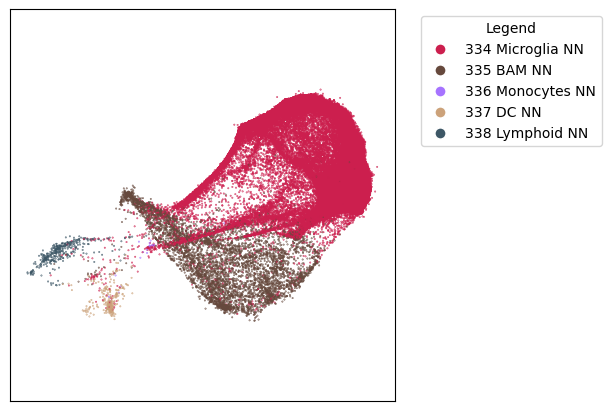

In [30]:
plot_labels(adata.obs['x'], adata.obs['y'], cc=adata.obs['subclass_color'], label_column=adata.obs['subclass'])

## Module Eigengene activation in UMAP

In [9]:
def plot_umap(data, x_col="x", y_col="y", color_col="turquoise", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots a UMAP visualization with a style similar to a minimal scatter plot.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the column to color.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        color_col (str): Column name for the color values.
        fig_width (float): Width of the figure.
        fig_height (float): Height of the figure.
        cmap (str): Colormap for the scatter plot.

    Returns:
        fig, ax: Matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    # Scatter plot with small marker size
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        s=0.5,
        c=data[color_col],
        cmap=cmap,
        marker='.',
        edgecolor='none'
    )

    # Set equal axis aspect ratio
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar
    fig.colorbar(scatter, ax=ax, orientation='vertical', label=color_col)

    return fig, ax

(<Figure size 400x400 with 2 Axes>, <Axes: >)

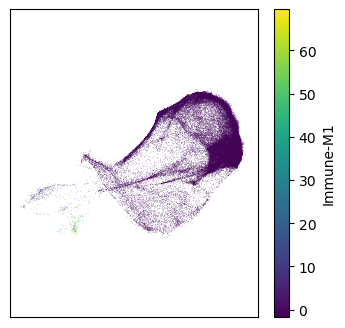

In [10]:
plot_umap(merged_df, color_col="Immune-M1")

In [11]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

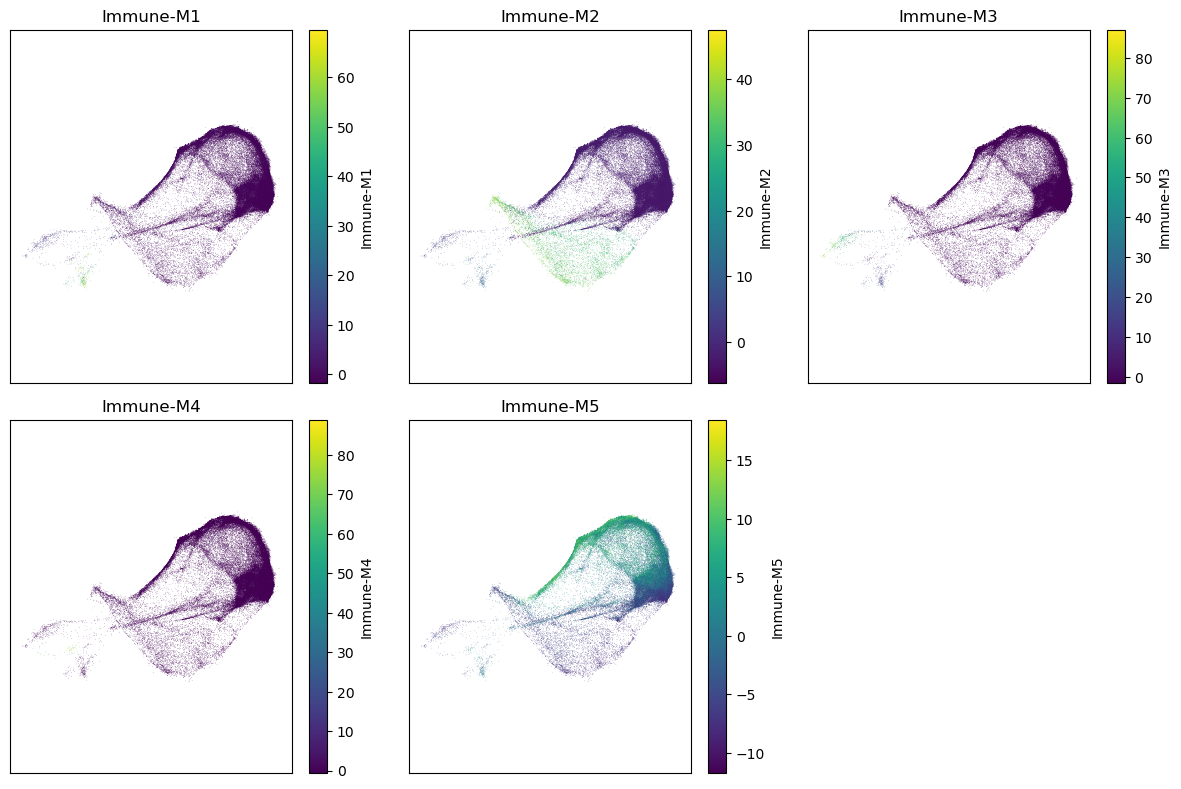

In [12]:
plot_multiple_umaps(merged_df, modules)

## Module Eigengenes across cell classes

In [15]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[modules])
adata_vis.obs["subclass"] = merged_df["subclass"]  # Add cell type labels

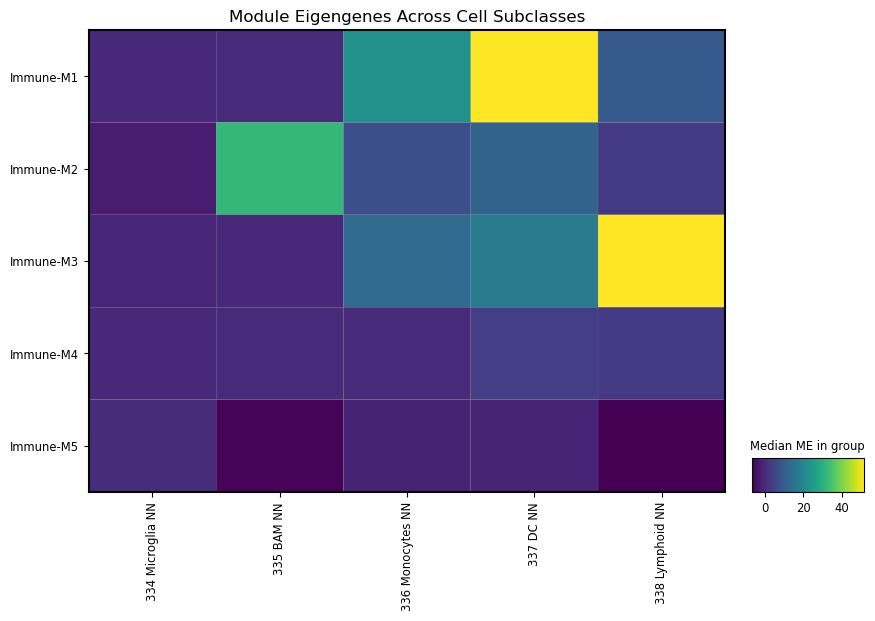

In [18]:
# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=modules,
    groupby="subclass",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Subclasses",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

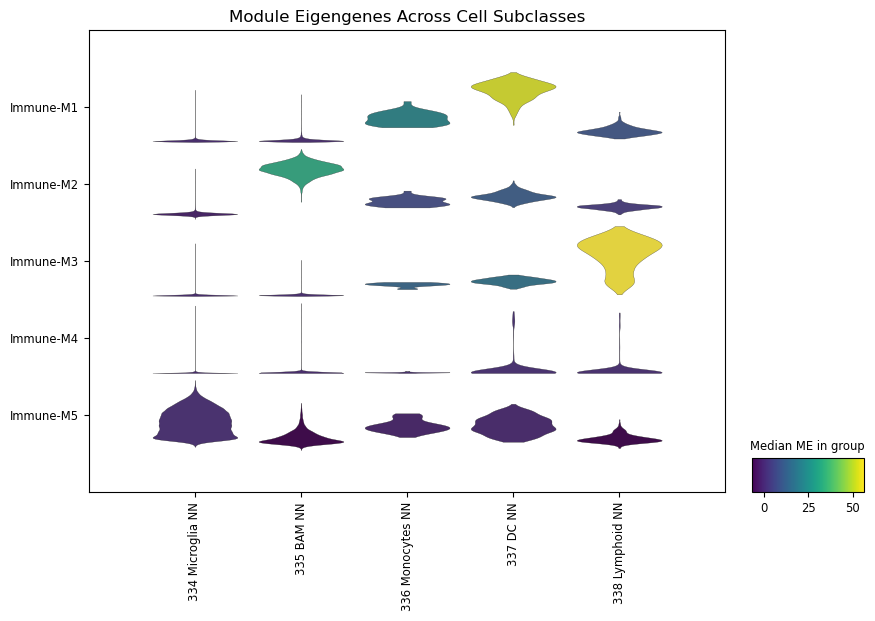

In [19]:
# Plot stacked violins
sc.pl.stacked_violin(
    adata_vis,
    var_names=modules,
    groupby="subclass",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Subclasses",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

# Quantifying module specificity

In [22]:
tau_scores = {}

for module in modules:
    tau_df = merged_df[["subclass", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('subclass', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Immune-M1 module: 0.816
Tau specificity score for Immune-M2 module: 0.708
Tau specificity score for Immune-M3 module: 0.829
Tau specificity score for Immune-M4 module: 0.681
Tau specificity score for Immune-M5 module: 0.351
